<a id="top"></a>
# Chapter 1 — Foundations: chains, SSH, graphene and flat bands

**PythTB — Tight-Binding Physics from Theory to Code** · Part I — Fundamentals · chapter 1 of 8

[◀ 0 Introduction](PythTB_00_Introduction.ipynb) · [Contents of the book](README.md) · [2 Finite systems, spin and the Berry-phase machinery ▶](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb)

**In this chapter**

- [§1 Theory — from wavefunctions to hoppings](#sec-1)
- [§2 The object model — `Lattice`, `TBModel`, and a first band structure](#sec-2)
- [§3 The SSH chain — two sites, one lesson](#sec-3)
- [§4 Graphene and boron nitride — Dirac cones and how to gap them](#sec-4)
- [§5 Flat bands — Lieb and kagome lattices](#sec-5)

All chapters: [0](PythTB_00_Introduction.ipynb) · [1](PythTB_01_Foundations.ipynb) · [2](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [3](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [4](PythTB_04_Chern_and_Z2.ipynb) · [5](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [6](PythTB_06_Weyl_and_Axion.ipynb) · [7](PythTB_07_Stretching_PythTB.ipynb) · [8](PythTB_08_What_PythTB_Cannot_Do.ipynb) · exercises: [Parts I–II](PythTB_Exercises_I-II.ipynb) · [Parts III–IV](PythTB_Exercises_III-IV.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them, and a chapter that reuses a model from an earlier one rebuilds it in a short recap cell. Section numbers (§1–31), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# the Wannier90 silicon data (§12) lives in data/ at the repository root
DATA_DIR = next((d for d in ("data", os.path.join("..", "data")) if os.path.isdir(d)), "data")

rng = np.random.default_rng(2026)          # single seed for every stochastic cell

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 0}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def draw_bonds(ax, xy, pairs, color="0.55", lw=1.0, ls="-", zorder=1):
    '''Draw a set of bonds (index pairs) between the 2D points xy on axis ax —
    used throughout to depict the actual system before computing on it.'''
    for i, j in pairs:
        ax.plot(xy[[i, j], 0], xy[[i, j], 1], ls, color=color, lw=lw, zorder=zorder)

print("pythtb", pythtb.__version__, "| numpy", np.__version__, "| chapter 1")
t_chapter_start = time.time()

pythtb 2.0.0 | numpy 2.5.2 | chapter 1


<a id="sec-1"></a>

# Part I — Fundamentals

## 1. Theory — from wavefunctions to hoppings

Start from a crystal Hamiltonian $H = -\tfrac{1}{2}\nabla^2 + V(\mathbf{r})$ with
$V(\mathbf{r}+\mathbf{R}) = V(\mathbf{r})$ for all lattice vectors $\mathbf{R}$. Two routes lead to
tight binding:

**LCAO route.** Pick a small set of atomic-like orbitals $\varphi_i(\mathbf{r}-\boldsymbol\tau_i)$
per unit cell and expand $\psi = \sum c_i \varphi_i$. Projecting the Schrödinger equation onto this
subspace gives a finite matrix problem per cell pair; the matrix elements
$t_{ij}(\mathbf{R}) = \langle \varphi_{i\mathbf{0}} | H | \varphi_{j\mathbf{R}} \rangle$
are the *hoppings* (off-site) and *site energies* (on-site, $\mathbf{R}=0$, $i=j$).

**Wannier route** (the one PythTB is really built around). Given a set of bands isolated by gaps,
Fourier-transform the Bloch states to maximally-localized Wannier functions
$|w_{i\mathbf{R}}\rangle$. The Hamiltonian in this basis is *exactly* tight-binding — no
approximation beyond the band truncation — and the hoppings decay exponentially with distance.
This is why a 4-orbital model can reproduce DFT silicon valence bands to meV accuracy (§12).

Either way, the object PythTB manipulates is
$$
H \;=\; \sum_{i\mathbf{R}} \varepsilon_i\, c^\dagger_{i\mathbf{R}} c_{i\mathbf{R}}
\;+\; \sum_{ij,\mathbf{R}\mathbf{R}'} t_{ij}(\mathbf{R}'-\mathbf{R})\,
      c^\dagger_{i\mathbf{R}} c_{j\mathbf{R}'} + \text{h.c.}
$$
Bloch's theorem block-diagonalizes it into an $N_{\rm orb}\times N_{\rm orb}$ matrix
$H(\mathbf{k})$ per k-point (with the convention-I phases fixed in the preamble), and *everything
PythTB computes* — bands, Berry phases, Chern numbers, Wannier centers — comes from dense
diagonalization of these small matrices on meshes, paths, or loops in $(\mathbf{k},\lambda)$ space.

That single sentence already contains the package's outer boundary: no self-consistency (the
$t_{ij}$ are inputs, never updated), no interactions (the Hamiltonian is strictly one-particle),
and no sparse or iterative linear algebra (every diagonalization is dense LAPACK). Part IV measures
where those walls sit.

<a id="sec-2"></a>

## 2. The object model — `Lattice`, `TBModel`, and a first band structure

PythTB 2.0 separates *geometry* from *Hamiltonian*:

- **`Lattice(lat_vecs, orb_vecs, periodic_dirs)`** — lattice vectors (Cartesian rows), orbital
  positions (reduced coordinates), and which directions are periodic. `periodic_dirs=...` means
  "all of them"; a finite cluster has `periodic_dirs=[]`. The classic v1 API encoded this in the
  `tb_model(dim_k, dim_r, ...)` pair of integers.
- **`TBModel(lattice, spinful=False)`** — holds $\varepsilon_i$ and $t_{ij}(\mathbf{R})$ via
  `set_onsite` / `set_hop`. Setting a hopping automatically sets its Hermitian partner: specify each
  bond **once**.
- Solvers: `solve_ham(k_pts)` → eigenvalues of shape `(nk, nstate)` (add
  `return_eigvecs=True` for states), `hamiltonian(k_pts)` → the raw Bloch matrices,
  `k_path(nodes, nk)` → interpolated path, `plot_bands(...)` → one-call band plot.

The mandatory first example: the monatomic chain, whose exact dispersion
$E(k) = \varepsilon_0 - 2t\cos(2\pi k)$ (reduced $k$) we check against the numerics.

In [2]:
# monatomic chain: one orbital, lattice constant 1, nearest-neighbour hopping t
t = 1.0
eps0 = 0.3

lat_chain = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0]], periodic_dirs=[0])
chain = TBModel(lat_chain)
chain.set_onsite([eps0])
chain.set_hop(-t, 0, 0, [1])      # hop to the right neighbour; h.c. is implicit

print(chain)                       # models pretty-print their full contents

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 1
k-space dimension           = 1
periodic directions         = [0]
spinful                     = False
number of spin components   = 1
number of electronic states = 1
number of orbitals          = 1

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000]
Volume of unit cell (Cartesian) = 1.000 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283]
Volume of reciprocal unit cell = 6.283 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.000]

Orbital vectors (fractional):
  # 0 ===> [ 0.000]
----------------------------------------
Site energies:
  < 0 | H | 0 > =  0.300 
Hoppings:
  < 0 | H | 0  + [ 1.0 ] > = -1.0000+0.0000j
Hopping distances:
  | pos( 0 ) - pos( 0 ) + [ 1.0 ] | =   1.000


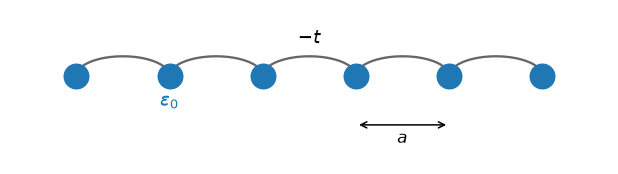

In [3]:
# the system itself, before any physics: sites, onsite energy, hopping
fig, ax = plt.subplots(figsize=(7, 1.8))
x_sites = np.arange(6)
ax.plot(x_sites, np.zeros(6), "o", ms=16, color="C0", zorder=3)
for x in x_sites[:-1]:
    # a bond drawn as an arc, labeled by its amplitude
    th = np.linspace(0, np.pi, 30)
    ax.plot(x + 0.5 + 0.5 * np.cos(th), 0.18 * np.sin(th), "-", color="0.4", lw=1.5)
ax.annotate(r"$-t$", (2.5, 0.30), ha="center", fontsize=12)
ax.annotate(r"$\varepsilon_0$", (1.0, -0.28), ha="center", fontsize=12, color="C0")
ax.annotate("", xy=(4.0, -0.45), xytext=(3.0, -0.45),
            arrowprops=dict(arrowstyle="<->", color="k", lw=1))
ax.annotate("$a$", (3.5, -0.62), ha="center", fontsize=11)
ax.set_xlim(-0.7, 5.7); ax.set_ylim(-0.8, 0.6)
ax.axis("off")
plt.show()
caption("The monatomic chain as PythTB stores it: one orbital per cell at onsite "
        "energy ε₀ (blue), nearest-neighbour hopping −t (arcs), lattice constant a. "
        "Every model in this notebook reduces to exactly this data: positions, "
        "onsite energies, and a list of hoppings.")

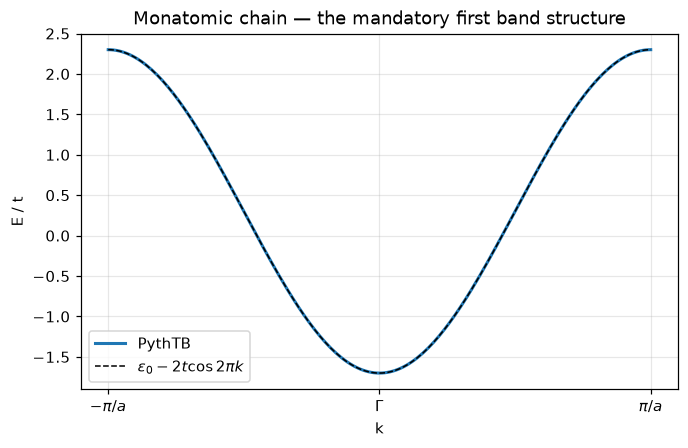

[PASS] chain dispersion matches -2t cos(2πk) — max dev = 0.00e+00


True

In [4]:
# solve on a k-path through the 1D Brillouin zone and compare with the exact band
k_vec, k_dist, k_node = chain.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
evals = chain.solve_ham(k_vec)

E_exact = eps0 - 2 * t * np.cos(2 * np.pi * k_vec[:, 0])

fig, ax = plt.subplots()
ax.plot(k_dist, evals[:, 0], lw=2, label="PythTB")
ax.plot(k_dist, E_exact, "k--", lw=1, label=r"$\varepsilon_0 - 2t\cos 2\pi k$")
ax.set_xticks(k_node, [r"$-\pi/a$", r"$\Gamma$", r"$\pi/a$"])
ax.set_xlabel("k")
ax.set_ylabel("E / t")
ax.legend()
ax.set_title("Monatomic chain — the mandatory first band structure")
plt.show()
caption("Band structure of the chain above: the numerical eigenvalues (solid) "
        "lie exactly on the analytic tight-binding cosine band (dashed). The bandwidth "
        "4t and the band minimum at Γ (for t > 0 in our sign convention) are the two "
        "numbers to read off any 1D band plot.")

check("chain dispersion matches -2t cos(2πk)",
      np.allclose(evals[:, 0], E_exact, atol=1e-12),
      f"max dev = {np.abs(evals[:, 0] - E_exact).max():.2e}")

In [5]:
# under the hood: H(k) is just a small dense matrix; convention I is visible in the phases
kpts = np.array([[0.0], [0.25], [0.25 + 1.0]])   # last point is k + G
H = chain.hamiltonian(kpts)
print("H(k) shapes:", H.shape)
print("H(0)      =", H[0].round(6))
print("H(1/4)    =", H[1].round(6))
print("H(1/4 + G)=", H[2].round(6))

check("H(k) is Hermitian at every k",
      all(np.allclose(h, h.conj().T) for h in H))
# with a single orbital at tau=0 convention I is periodic; the tau-dependence shows up
# in multi-orbital models below — remember it when comparing matrices with papers

H(k) shapes: (3, 1, 1)
H(0)      = [[-1.7+0.j]]
H(1/4)    = [[0.3+0.j]]
H(1/4 + G)= [[0.3+0.j]]
[PASS] H(k) is Hermitian at every k


True

<a id="sec-3"></a>

## 3. The SSH chain — two sites, one lesson

The Su–Schrieffer–Heeger chain is the simplest model with a band topology: two orbitals per cell,
alternating hoppings $v$ (intracell) and $w$ (intercell),
$$
H(k) = \begin{pmatrix} 0 & v + w\,e^{-2\pi i k} \\ v + w\,e^{2\pi i k} & 0 \end{pmatrix}
\quad\text{(convention II form)},
$$
with spectrum $E_\pm(k) = \pm|v + w e^{2\pi i k}|$: gapped whenever $v \neq w$, with gap
$2|v - w|$ at the zone boundary, and two *distinct* insulators ($v>w$ trivial, $v<w$ topological)
that cannot be connected without closing the gap. The invariant that distinguishes them — the Berry
phase / winding number — is computed in §9; here we establish the spectra.

This section also shows off a genuinely new 2.0 feature: **symbolic parameters**. A hopping can be
the *string* `"w"`, and `solve_ham` then broadcasts over arrays passed as keyword arguments — a full
phase diagram in one call, no Python loop.

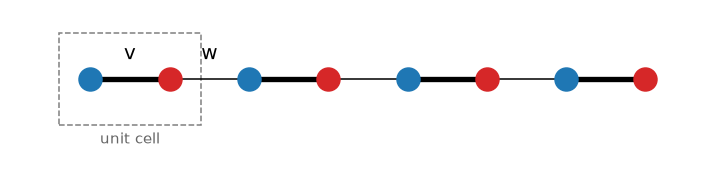

In [6]:
# the SSH geometry: a two-site cell with alternating strong/weak bonds
fig, ax = plt.subplots(figsize=(8, 1.9))
xa = np.arange(4)                       # unit cells
for c in xa:
    ax.plot([c], [0], "o", ms=15, color="C0", zorder=3)          # orbital 0
    ax.plot([c + 0.5], [0], "o", ms=15, color="C3", zorder=3)    # orbital 1
    ax.plot([c, c + 0.5], [0, 0], "-", color="k", lw=3.5, zorder=2)      # v (intracell)
    if c < xa[-1]:
        ax.plot([c + 0.5, c + 1], [0, 0], "-", color="k", lw=1.0, zorder=2)  # w
ax.annotate("v", (0.25, 0.13), ha="center", fontsize=13)
ax.annotate("w", (0.75, 0.13), ha="center", fontsize=13)
ax.add_patch(plt.Rectangle((-0.2, -0.3), 0.9, 0.6, fill=False, ls="--", ec="0.5"))
ax.annotate("unit cell", (0.25, -0.42), ha="center", fontsize=10, color="0.4")
ax.set_xlim(-0.5, 3.8); ax.set_ylim(-0.6, 0.45); ax.axis("off")
plt.show()
caption("The SSH chain: two orbitals per cell (blue at τ = 0, red at τ = ½) with "
        "alternating intracell hopping v (thick) and intercell hopping w (thin). "
        "Which bond is 'inside' the cell is a choice — but once the chain ends "
        "somewhere, the choice of where to cut becomes physical, and that is the "
        "entire topological story of this model.")

free parameters: [{'kind': 'hopping', 'orbitals': (1, 0), 'R': (1,), 'names': ('w',)}]
broadcast eigenvalue array: (201, 3, 2)


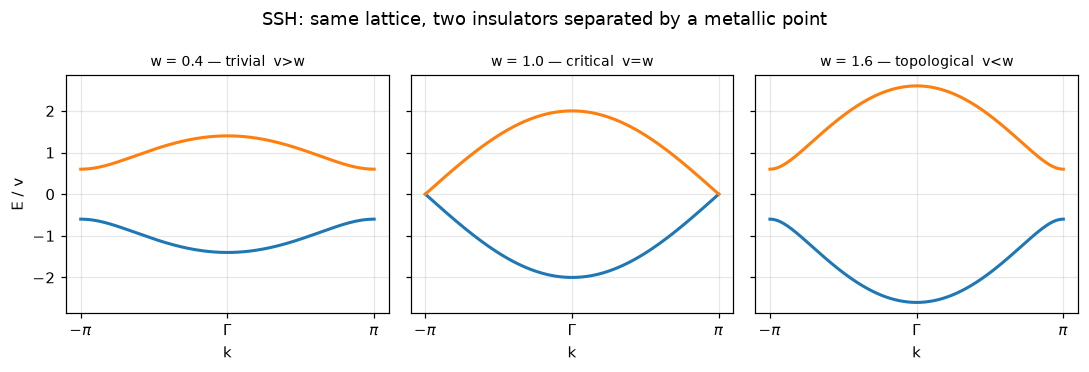

[PASS] SSH gap equals 2|v-w| — gap = 1.200000


True

In [7]:
# SSH with symbolic intercell hopping w (v fixed): one model, many Hamiltonians
v = 1.0
lat_ssh = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.5]], periodic_dirs=[0])
ssh = TBModel(lat_ssh)
ssh.set_hop(v, 0, 1, [0])         # intracell bond
ssh.set_hop("w", 1, 0, [1])       # intercell bond — symbolic
print("free parameters:", ssh.parameters)

k_vec, k_dist, k_node = ssh.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
w_values = np.array([0.4, 1.0, 1.6])
evals = ssh.solve_ham(k_vec, w=w_values)        # shape (nk, nw, 2) — broadcast over w
print("broadcast eigenvalue array:", evals.shape)
evals = np.moveaxis(evals, 1, 0)                # -> (nw, nk, 2) for plotting

fig, axs = plt.subplots(1, 3, figsize=(10, 3.4), sharey=True)
for ax, wv, ev, tag in zip(axs, w_values, evals,
                           ["trivial  v>w", "critical  v=w", "topological  v<w"]):
    ax.plot(k_dist, ev, lw=2)
    ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
    ax.set_title(f"w = {wv:.1f} — {tag}", fontsize=9)
    ax.set_xlabel("k")
axs[0].set_ylabel("E / v")
fig.suptitle("SSH: same lattice, two insulators separated by a metallic point")
fig.tight_layout()
plt.show()
caption("SSH bands for three dimerizations, computed from ONE symbolic model by "
        "broadcasting over w. The spectra of w = 0.4 and w = 1.6 look identical — "
        "band energies cannot distinguish the two insulators — yet they are "
        "topologically distinct: no smooth deformation connects them without passing "
        "through the gapless point w = v (middle panel).")

gap = 2 * evals[0, :, 1].min()    # w=0.4: full gap = 2(v-w)
check("SSH gap equals 2|v-w|", np.isclose(gap, 2 * (v - 0.4), atol=1e-10),
      f"gap = {gap:.6f}")

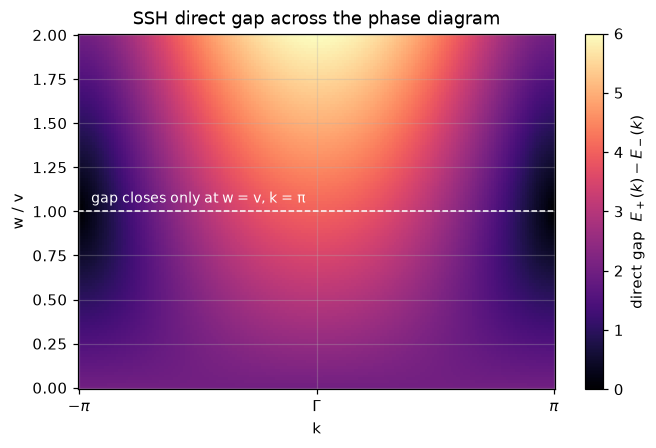

In [8]:
# continuous gap map E(k, w): dense diagonalization is cheap at this size —
# 201 k-points x 121 w-values = 24k 2x2 matrices in one vectorized call
w_scan = np.linspace(0.0, 2.0, 121)
ev_scan = np.moveaxis(ssh.solve_ham(k_vec, w=w_scan), 1, 0)   # -> (nw, nk, 2)
direct_gap = ev_scan[:, :, 1] - ev_scan[:, :, 0]

fig, ax = plt.subplots()
im = ax.pcolormesh(k_dist, w_scan, direct_gap, cmap="magma", shading="auto")
fig.colorbar(im, label=r"direct gap  $E_+(k) - E_-(k)$")
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.axhline(1.0, color="w", ls="--", lw=1)
ax.text(k_dist[5], 1.05, "gap closes only at w = v, k = π", color="w", fontsize=9)
ax.set_xlabel("k")
ax.set_ylabel("w / v")
ax.set_title("SSH direct gap across the phase diagram")
plt.show()
caption("The direct gap over the whole (k, w) plane: it vanishes at exactly one "
        "point, (k, w) = (π, v). Any path from the trivial (bottom) to the "
        "topological (top) region must cross that point — a gap closing is the "
        "unavoidable toll of a topological transition.")

<a id="sec-4"></a>

## 4. Graphene and boron nitride — Dirac cones and how to gap them

Honeycomb lattice: triangular Bravais lattice $\mathbf{a}_1 = (1,0)$,
$\mathbf{a}_2 = (\tfrac12, \tfrac{\sqrt3}{2})$ with two sublattices A, B at reduced positions
$(\tfrac13,\tfrac13)$ and $(\tfrac23,\tfrac23)$. Nearest-neighbour hopping $t$ gives
$$
E_\pm(\mathbf{k}) = \pm |t|\,\bigl|1 + e^{2\pi i k_1} + e^{2\pi i k_2}\bigr|
      \;\mp\; \text{(sign fixed by convention)},
$$
which vanishes at the two inequivalent corners $K = (\tfrac23,\tfrac13)$, $K' = (\tfrac13,\tfrac23)$
of the Brillouin zone — the Dirac points. Near them the dispersion is linear (massless Dirac
fermions). A sublattice-staggered onsite $\pm\Delta$ (this *is* hexagonal boron nitride, chemically)
breaks inversion and opens a gap $2\Delta$ at $K$: same lattice, insulator instead of semimetal.

PythTB ships factory functions in `pythtb.models`; we build graphene by hand once, cross-check
against the factory, and use `plot_bands` with sublattice projection to color the bands.

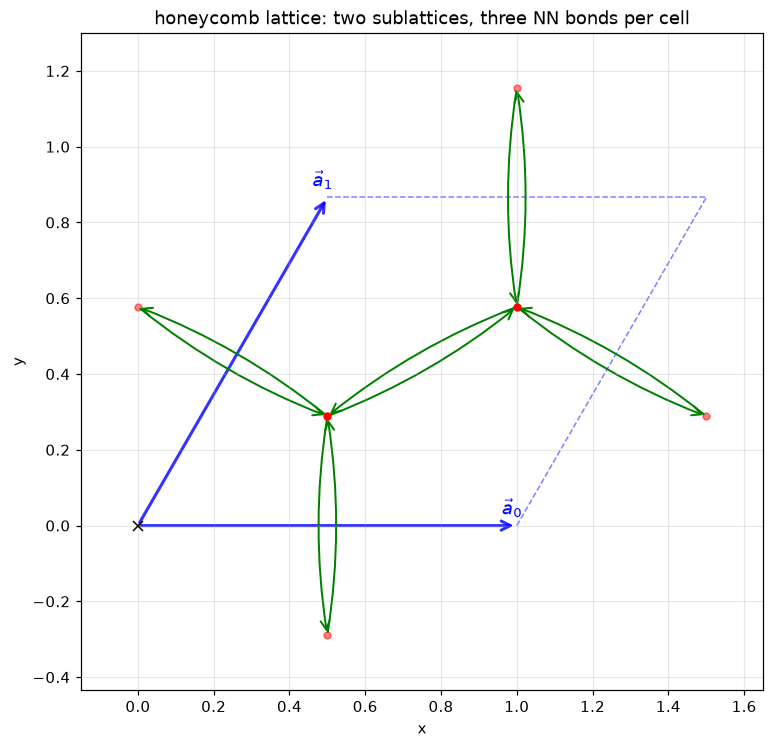

[PASS] hand-built graphene = pythtb.models.graphene


True

In [9]:
def honeycomb(delta, t):
    '''Honeycomb-lattice model with staggered onsite ±delta and NN hopping t.'''
    lat = Lattice(lat_vecs=[[1.0, 0.0], [0.5, np.sqrt(3) / 2]],
                  orb_vecs=[[1/3, 1/3], [2/3, 2/3]], periodic_dirs=[0, 1])
    m = TBModel(lat)
    m.set_onsite([-delta, delta])
    m.set_hop(t, 0, 1, [0, 0])
    m.set_hop(t, 1, 0, [1, 0])
    m.set_hop(t, 1, 0, [0, 1])
    return m

graphene = honeycomb(delta=0.0, t=-1.0)
graphene.visualize()
plt.title("honeycomb lattice: two sublattices, three NN bonds per cell")
plt.show()
caption("The honeycomb lattice as PythTB sees it (built-in visualize): sublattice A "
        "and B orbitals, the two lattice vectors, and the three nearest-neighbour "
        "bonds each cell contributes. The two-site basis — not the hexagonal shape — "
        "is what produces two bands and makes a Dirac point possible.")

# cross-check our hand-built model against the shipped factory on random k-points
from pythtb.models import graphene as graphene_factory
k_rand = rng.random((40, 2))
check("hand-built graphene = pythtb.models.graphene",
      np.allclose(graphene.solve_ham(k_rand),
                  graphene_factory(delta=0.0, t=-1.0).solve_ham(k_rand), atol=1e-12))

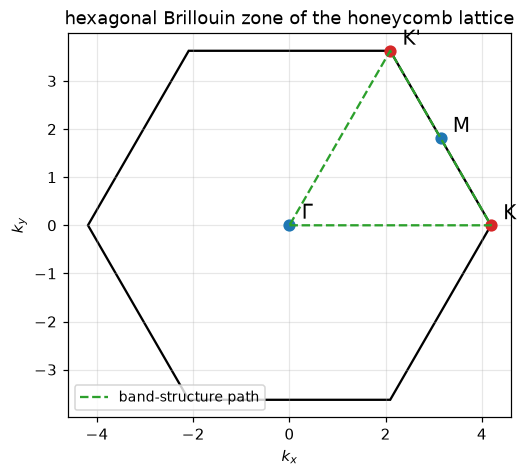

In [10]:
# the Brillouin zone and the path we will walk through it
b1 = graphene.recip_lat_vecs[0]
b2 = graphene.recip_lat_vecs[1]
corners_red = [[2/3, 1/3], [1/3, 2/3], [-1/3, 1/3], [-2/3, -1/3], [-1/3, -2/3], [1/3, -1/3]]
corners = np.array([c[0] * b1 + c[1] * b2 for c in corners_red])

fig, ax = plt.subplots(figsize=(5.2, 5))
hexagon = plt.Polygon(corners, fill=False, ec="k", lw=1.5)
ax.add_patch(hexagon)
for c_red, name in [([2/3, 1/3], "K"), ([1/3, 2/3], "K'"), ([1/2, 1/2], "M"),
                    ([0, 0], r"$\Gamma$")]:
    p = c_red[0] * b1 + c_red[1] * b2
    ax.plot(*p, "o", ms=7, color="C3" if name in ("K", "K'") else "C0")
    ax.annotate(name, p, textcoords="offset points", xytext=(8, 4), fontsize=13)
path = np.array([[0, 0], [2/3, 1/3], [1/2, 1/2], [1/3, 2/3], [0, 0]]) @ graphene.recip_lat_vecs
ax.plot(path[:, 0], path[:, 1], "--", color="C2", lw=1.5, label="band-structure path")
ax.set_aspect("equal"); ax.legend(loc="lower left", fontsize=9)
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_y$")
ax.set_title("hexagonal Brillouin zone of the honeycomb lattice")
plt.show()
caption("The Brillouin zone with the high-symmetry points and the Γ–K–M–K'–Γ path "
        "used in every honeycomb band plot below. K and K' (red) are the two "
        "inequivalent zone corners where the Dirac cones live; they are NOT related "
        "by a reciprocal lattice vector, which is why breaking the symmetry between "
        "them (as the Haldane model does in §14) has physical consequences.")

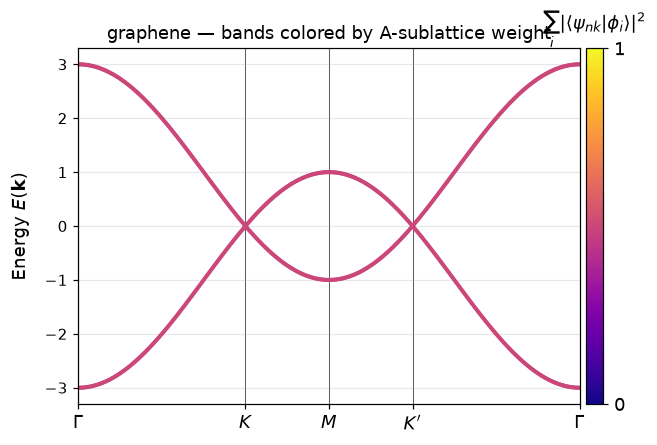

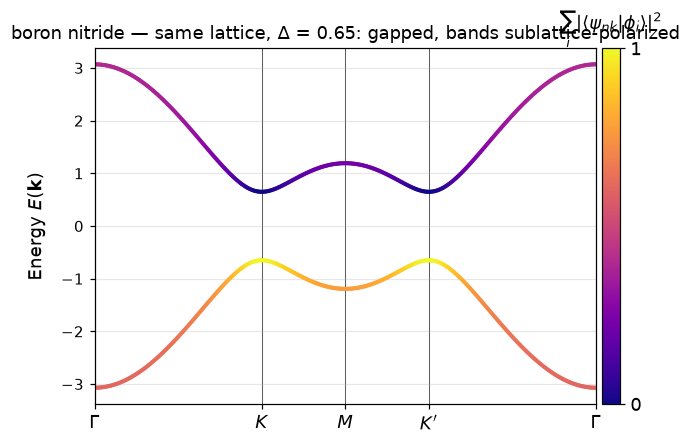

[PASS] graphene bands touch at K — E gap at K = 6.28e-16
[PASS] BN gap at K equals 2Δ — gap = 1.300000


True

In [11]:
K_NODES_HEX = [[0, 0], [2/3, 1/3], [1/2, 1/2], [1/3, 2/3], [0, 0]]
K_LABELS_HEX = [r"$\Gamma$", r"$K$", r"$M$", r"$K'$", r"$\Gamma$"]

fig, ax = graphene.plot_bands(K_NODES_HEX, k_node_labels=K_LABELS_HEX, nk=401,
                              proj_orb_idx=[0], cbar=True)
ax.set_title("graphene — bands colored by A-sublattice weight")
plt.show()
caption("Graphene bands along the BZ path just shown, colored by the weight of each "
        "state on sublattice A. Away from the Dirac points the bands mix both "
        "sublattices equally (green); the linear crossings at K and K' are protected "
        "by the equivalence of the two sublattices — inversion symmetry.")

# boron nitride: identical lattice, staggered onsite breaks inversion, gap = 2Δ
delta_bn = 0.65
bn = honeycomb(delta=delta_bn, t=-1.0)
fig, ax = bn.plot_bands(K_NODES_HEX, k_node_labels=K_LABELS_HEX, nk=401,
                        proj_orb_idx=[0], cbar=True)
ax.set_title(f"boron nitride — same lattice, Δ = {delta_bn}: gapped, bands sublattice-polarized")
plt.show()
caption("Boron nitride: chemically, B and N atoms make the two sublattices "
        "inequivalent — modeled by the staggered onsite ±Δ. The Dirac points gap out "
        "and the band coloring shows the physics: the valence band concentrates on "
        "the low-energy (N-like) sublattice, the conduction band on the other. Same "
        "lattice, same hoppings — a semimetal became an insulator by symmetry breaking.")

evK = np.atleast_2d(graphene.solve_ham(np.array([[2/3, 1/3]])))
check("graphene bands touch at K", np.isclose(evK[0, 1] - evK[0, 0], 0.0, atol=1e-12),
      f"E gap at K = {evK[0, 1] - evK[0, 0]:.2e}")
evK_bn = np.atleast_2d(bn.solve_ham(np.array([[2/3, 1/3]])))
check("BN gap at K equals 2Δ",
      np.isclose(evK_bn[0, 1] - evK_bn[0, 0], 2 * delta_bn, atol=1e-10),
      f"gap = {evK_bn[0, 1] - evK_bn[0, 0]:.6f}")

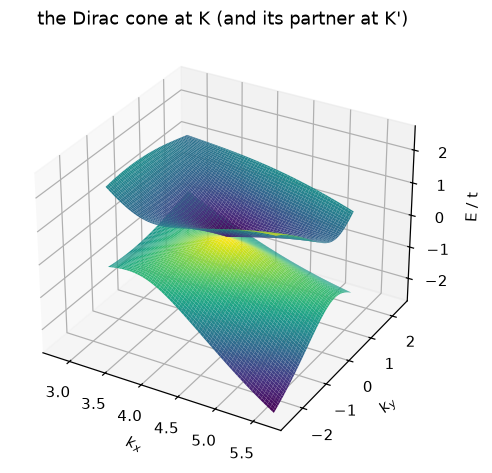

In [12]:
# the Dirac cone as a surface: E(kx, ky) on a mesh around K
nk = 120
k1 = np.linspace(0.45, 0.90, nk)
k2 = np.linspace(0.10, 0.55, nk)
K1, K2 = np.meshgrid(k1, k2, indexing="ij")
k_mesh = np.stack([K1.ravel(), K2.ravel()], axis=1)
ev = graphene.solve_ham(k_mesh).reshape(nk, nk, 2)

# convert reduced k to Cartesian for an undistorted picture
k_cart = k_mesh @ graphene.recip_lat_vecs
KX = k_cart[:, 0].reshape(nk, nk)
KY = k_cart[:, 1].reshape(nk, nk)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(KX, KY, ev[:, :, 0], cmap="viridis", rstride=2, cstride=2, lw=0)
ax.plot_surface(KX, KY, ev[:, :, 1], cmap="viridis", rstride=2, cstride=2, lw=0)
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_y$"); ax.set_zlabel("E / t")
ax.set_title("the Dirac cone at K (and its partner at K')")
plt.show()
caption("The energy surface E(kx, ky) near the zone corner: the two bands meet in a "
        "cone — dispersion linear in every direction, the hallmark of massless Dirac "
        "fermions. The slope is the Fermi velocity; in real graphene it is c/300, "
        "which is why relativistic phenomenology shows up at meV energies.")

<a id="sec-5"></a>

## 5. Flat bands — Lieb and kagome lattices

Not every band disperses. On the **Lieb lattice** (a square lattice with extra sites on the bond
midpoints — the CuO₂ geometry) destructive interference pins one band exactly at $E = 0$ for any
$\mathbf{k}$: eigenstates live only on the edge sites with alternating signs, and the hopping
amplitudes cancel identically. On the **kagome lattice** (corner-sharing triangles) the same
mechanism produces a flat band touching a dispersive band quadratically.

Flat bands are where interactions would dominate (any $U$ beats zero bandwidth) — and a running
reminder that PythTB stops exactly at that point: it can *locate* flat bands but says nothing about
the correlated states they host (Part IV, §29).

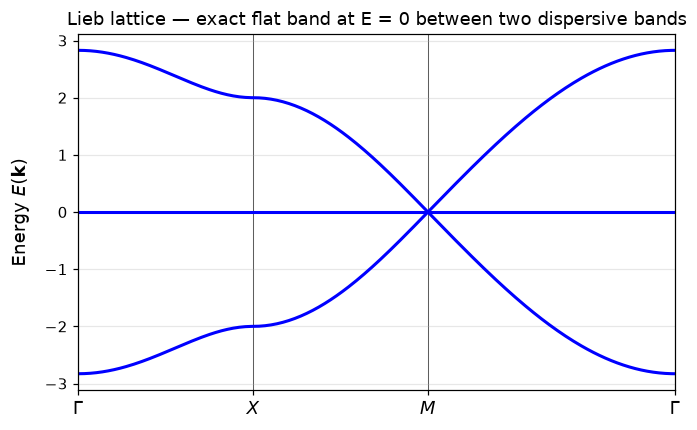

[PASS] Lieb middle band is exactly flat at E=0 — max |E| = 0.00e+00


True

In [13]:
# Lieb lattice: corner site (0,0), edge sites (1/2,0) and (0,1/2) on a square lattice
lat_lieb = Lattice(lat_vecs=[[1, 0], [0, 1]],
                   orb_vecs=[[0, 0], [0.5, 0], [0, 0.5]], periodic_dirs=[0, 1])
lieb = TBModel(lat_lieb)
t = -1.0
lieb.set_hop(t, 0, 1, [0, 0]); lieb.set_hop(t, 1, 0, [1, 0])   # corner-edge along x
lieb.set_hop(t, 0, 2, [0, 0]); lieb.set_hop(t, 2, 0, [0, 1])   # corner-edge along y

SQ_NODES = [[0, 0], [0.5, 0], [0.5, 0.5], [0, 0]]
SQ_LABELS = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
fig, ax = lieb.plot_bands(SQ_NODES, k_node_labels=SQ_LABELS, nk=301)
ax.set_title("Lieb lattice — exact flat band at E = 0 between two dispersive bands")
plt.show()
caption("Lieb-lattice bands: two dispersive bands touching a perfectly flat band at "
        "E = 0. Flat means infinite effective mass — electrons in this band cannot "
        "propagate at all, because every state is built from the interference-locked "
        "plaquette configurations shown in the next figure.")

k_rand = rng.random((300, 2))
ev = lieb.solve_ham(k_rand)
flat = ev[:, 1]                     # middle band
check("Lieb middle band is exactly flat at E=0",
      np.abs(flat).max() < 1e-12, f"max |E| = {np.abs(flat).max():.2e}")

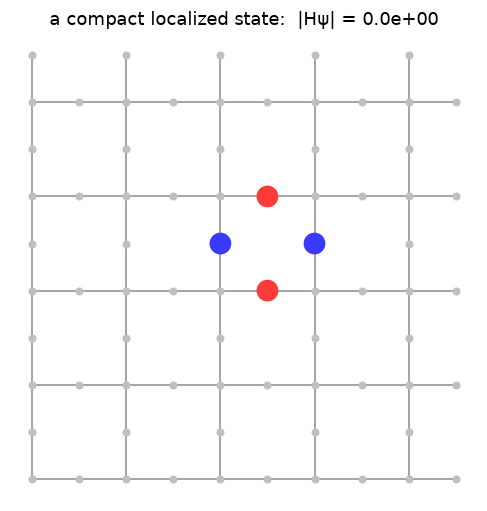

[PASS] hand-built plaquette state is an exact E = 0 eigenstate — max residual = 0.0e+00


True

In [14]:
# WHY the band is flat: an explicit compact localized state (CLS). Put amplitudes
# +1 and -1 on the four edge sites around one plaquette and nothing anywhere else;
# every corner site receives t(+1) + t(-1) = 0 — the state cannot leak, so it is
# an exact eigenstate at E = 0 despite living on only four sites.
L_cls = 5
lieb_fin = lieb.make_finite(periodic_dirs=[0, 1], num_cells=[L_cls, L_cls])
pos = lieb_fin.orb_vecs @ lieb_fin.lat_vecs

psi = np.zeros(lieb_fin.norb)
# ring of 4 edge sites around a PLAQUETTE CENTER (n+1/2, m+1/2) near the middle
# of the sample — each corner of that square then touches exactly two ring sites
# of opposite sign
pc = np.round(pos.mean(0) - 0.5) + 0.5               # nearest plaquette center
d = np.linalg.norm(pos - pc, axis=1)
ring = np.where(np.abs(d - 0.5) < 1e-6)[0]            # the 4 surrounding edge sites
ang = np.arctan2(*(pos[ring] - pc).T[::-1])           # order them around the ring
ring = ring[np.argsort(ang)]
psi[ring] = [1, -1, 1, -1]                            # alternating signs
psi = psi / np.linalg.norm(psi)

# verify it is an exact zero-energy eigenstate of the FINITE sample
H_fin = lieb_fin.hamiltonian()
residual = np.abs(H_fin @ psi).max()

fig, ax = plt.subplots(figsize=(6, 5.5))
d2p = np.sum((pos[:, None, :] - pos[None, :, :]) ** 2, axis=-1)
draw_bonds(ax, pos, [(i, j) for i, j in zip(*np.where(np.abs(d2p - 0.25) < 1e-6)) if i < j])
ax.scatter(pos[:, 0], pos[:, 1], s=18, c="0.75", zorder=2)
sc = ax.scatter(pos[ring, 0], pos[ring, 1], s=350 * np.abs(psi[ring]),
                c=np.sign(psi[ring]), cmap="bwr", vmin=-1.3, vmax=1.3, zorder=3)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"a compact localized state:  |Hψ| = {residual:.1e}")
plt.show()
caption("The flat band, explained in one picture: a state with alternating signs "
        "(red/blue) on the four edge sites of a single plaquette. Each neighbouring "
        "corner site couples to a +1 and a −1 with equal hopping, so the amplitudes "
        "cancel exactly and the state is a strict eigenstate at E = 0. One such state "
        "exists per plaquette — a macroscopically degenerate band of them.")

check("hand-built plaquette state is an exact E = 0 eigenstate",
      residual < 1e-12, f"max residual = {residual:.1e}")

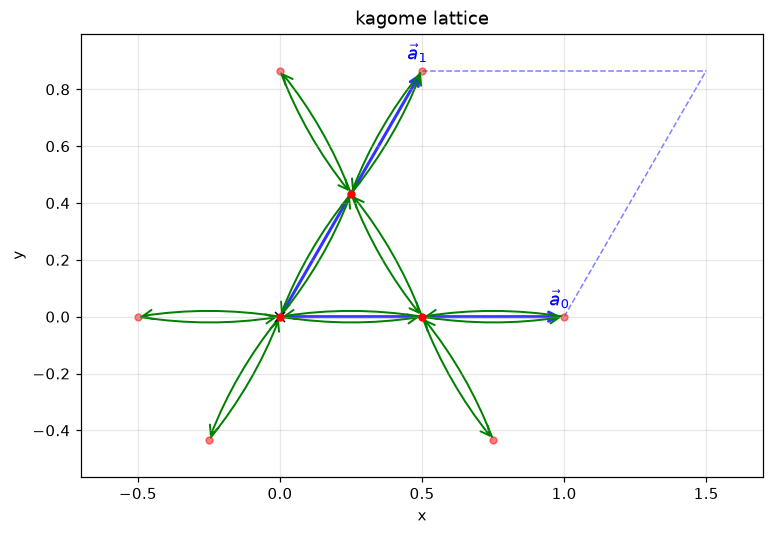

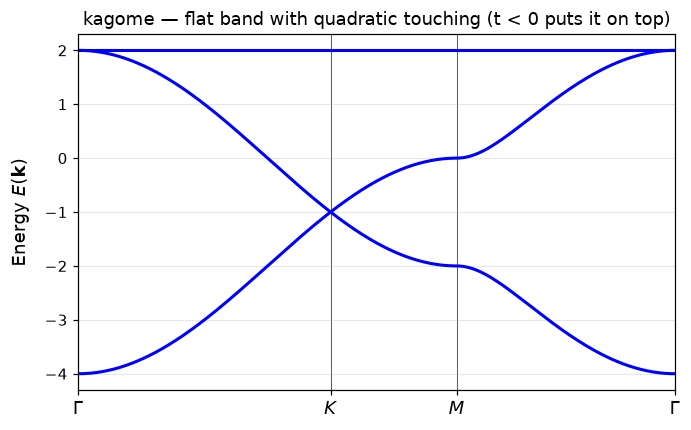

[PASS] kagome has an exactly flat band at E = -2t — spread = 2.66e-15 around E = 2.000


True

In [15]:
# kagome lattice: three sites per triangular cell, corner-sharing triangles
lat_kag = Lattice(lat_vecs=[[1, 0], [0.5, np.sqrt(3) / 2]],
                  orb_vecs=[[0, 0], [0.5, 0], [0, 0.5]], periodic_dirs=[0, 1])
kagome = TBModel(lat_kag)
t = -1.0
kagome.set_hop(t, 0, 1, [0, 0]); kagome.set_hop(t, 0, 1, [-1, 0])
kagome.set_hop(t, 0, 2, [0, 0]); kagome.set_hop(t, 0, 2, [0, -1])
kagome.set_hop(t, 1, 2, [0, 0]); kagome.set_hop(t, 1, 2, [1, -1])

kagome.visualize()
plt.title("kagome lattice")
plt.show()
caption("The kagome lattice: corner-sharing triangles, three sites per cell. "
        "Geometric frustration — every closed loop of bonds has odd length 3 — is "
        "what breaks particle-hole symmetry and pins the flat band at the TOP of the "
        "spectrum for t < 0 rather than in the middle.")

TRI_NODES = [[0, 0], [2/3, 1/3], [1/2, 1/2], [0, 0]]
TRI_LABELS = [r"$\Gamma$", r"$K$", r"$M$", r"$\Gamma$"]
fig, ax = kagome.plot_bands(TRI_NODES, k_node_labels=TRI_LABELS, nk=301)
ax.set_title("kagome — flat band with quadratic touching (t < 0 puts it on top)")
plt.show()
caption("Kagome bands: a Dirac crossing at K (graphene-like, from the underlying "
        "triangular Bravais lattice) plus an exactly flat band touching the middle "
        "band quadratically at Γ. The kagome CLS lives on a hexagon with alternating "
        "signs; unlike the Lieb case the touching makes the flat band's topology "
        "singular — it cannot be spanned by exponentially localized Wannier functions.")

ev = kagome.solve_ham(rng.random((300, 2)))
flat = ev[:, 2]
check("kagome has an exactly flat band at E = -2t",
      np.allclose(flat, -2 * t, atol=1e-12),
      f"spread = {flat.max() - flat.min():.2e} around E = {flat.mean():.3f}")

In [16]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 1 — checks passed : {_CHECKS['pass']}")
print(f"chapter 1 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 1 — checks passed : 9
chapter 1 — checks failed : 0
wall time                 : 7 s
Every quantitative claim in this notebook was verified in this run.
